In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
from collections import deque

## Data Demostartion

In [8]:
df = pd.read_csv('Data/Raw_data/IM2606_20260515.csv', usecols=[0] + list(range(5, 25)))
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,bidSize1,bidSize2,bidSize3,bidSize4,bidSize5,askSize1,askSize2,askSize3,askSize4,askSize5
0,20260515 09:29:00.113806,8710.0,8709.8,8705.8,8705.0,8704.8,8711.0,8711.8,8712.2,8712.4,...,5.0,3.0,2.0,5.0,1.0,1.0,8.0,5.0,2.0,1.0
1,20260515 09:30:00.519956,8710.0,8709.8,8705.8,8705.0,8704.8,8710.2,8717.0,8717.6,8717.8,...,7.0,7.0,2.0,5.0,1.0,1.0,2.0,1.0,7.0,4.0
2,20260515 09:30:01.021552,8711.2,8711.0,8710.2,8710.0,8709.8,8716.4,8718.0,8718.6,8718.8,...,1.0,1.0,23.0,21.0,9.0,11.0,3.0,2.0,1.0,1.0
3,20260515 09:30:01.519457,8711.6,8711.4,8711.2,8711.0,8710.4,8713.2,8714.8,8715.0,8715.2,...,1.0,30.0,3.0,5.0,37.0,1.0,1.0,1.0,1.0,1.0
4,20260515 09:30:02.018199,8716.4,8714.6,8713.6,8713.4,8713.2,8716.6,8718.0,8718.6,8718.8,...,1.0,1.0,1.0,4.0,8.0,1.0,8.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28728,20260515 14:59:58.059378,8582.2,8580.4,8580.2,8580.0,8579.6,8582.6,8587.2,8588.0,8588.8,...,3.0,1.0,8.0,3.0,2.0,1.0,5.0,10.0,1.0,3.0
28729,20260515 14:59:58.562878,8582.6,8581.6,8580.4,8580.2,8580.0,8585.0,8588.0,8588.8,8589.0,...,1.0,10.0,1.0,8.0,3.0,2.0,10.0,1.0,3.0,1.0
28730,20260515 14:59:59.059372,8581.6,8580.4,8580.2,8580.0,8579.6,8582.8,8585.0,8588.0,8588.8,...,8.0,1.0,8.0,3.0,2.0,5.0,1.0,10.0,1.0,3.0
28731,20260515 14:59:59.561837,8581.8,8581.6,8580.4,8580.2,8580.0,8582.8,8585.0,8588.0,8588.8,...,1.0,9.0,1.0,8.0,3.0,1.0,1.0,10.0,1.0,3.0


In [9]:
df['MidPrice'] = (df['bid1'] + df['ask1']) / 2
df['MidPrice']


0        8710.5
1        8710.1
2        8713.8
3        8712.4
4        8716.5
          ...  
28728    8582.4
28729    8583.8
28730    8582.2
28731    8582.3
28732    8582.1
Name: MidPrice, Length: 28733, dtype: float64

In [10]:
def price_micro(df, level: int):
    price_cols = [f'bid{level}', f'ask{level}']
    size_cols = [f'bidSize{level}', f'askSize{level}']   
    df[f'price_micro_{level}'] = (df[price_cols[0]] * df[size_cols[1]] + df[price_cols[1]] * df[size_cols[0]]) / (df[size_cols[0]] + df[size_cols[1]])
    return None

In [11]:
for i in range(1,6):
    price_micro(df, level = i)
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,askSize2,askSize3,askSize4,askSize5,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5
0,20260515 09:29:00.113806,8710.0,8709.8,8705.8,8705.0,8704.8,8711.0,8711.8,8712.2,8712.4,...,8.0,5.0,2.0,1.0,8710.5,8710.833333,8710.345455,8707.628571,8710.285714,8708.900000
1,20260515 09:30:00.519956,8710.0,8709.8,8705.8,8705.0,8704.8,8710.2,8717.0,8717.6,8717.8,...,2.0,1.0,7.0,4.0,8710.1,8710.175000,8715.400000,8713.666667,8710.333333,8707.440000
2,20260515 09:30:01.021552,8711.2,8711.0,8710.2,8710.0,8709.8,8716.4,8718.0,8718.6,8718.8,...,3.0,2.0,1.0,1.0,8713.8,8711.633333,8712.750000,8717.928000,8718.400000,8718.080000
3,20260515 09:30:01.519457,8711.6,8711.4,8711.2,8711.0,8710.4,8713.2,8714.8,8715.0,8715.2,...,1.0,1.0,1.0,1.0,8712.4,8712.400000,8714.690323,8714.050000,8714.500000,8715.463158
4,20260515 09:30:02.018199,8716.4,8714.6,8713.6,8713.4,8713.2,8716.6,8718.0,8718.6,8718.8,...,8.0,2.0,1.0,1.0,8716.5,8716.500000,8714.977778,8715.266667,8717.720000,8718.355556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28728,20260515 14:59:58.059378,8582.2,8580.4,8580.2,8580.0,8579.6,8582.6,8587.2,8588.0,8588.8,...,5.0,10.0,1.0,3.0,8582.4,8582.500000,8581.533333,8583.666667,8586.600000,8583.360000
28729,20260515 14:59:58.562878,8582.6,8581.6,8580.4,8580.2,8580.0,8585.0,8588.0,8588.8,8589.0,...,10.0,1.0,3.0,1.0,8583.8,8583.400000,8584.800000,8584.600000,8586.600000,8587.050000
28730,20260515 14:59:59.059372,8581.6,8580.4,8580.2,8580.0,8579.6,8582.8,8585.0,8588.0,8588.8,...,1.0,10.0,1.0,3.0,8582.2,8582.338462,8582.700000,8583.666667,8586.600000,8583.360000
28731,20260515 14:59:59.561837,8581.8,8581.6,8580.4,8580.2,8580.0,8582.8,8585.0,8588.0,8588.8,...,1.0,10.0,1.0,3.0,8582.3,8582.300000,8584.660000,8581.090909,8587.844444,8584.500000


In [12]:
df_selected = pd.concat([df.iloc[:, [0]], df.iloc[:, -6:]], axis=1)
df_selected['price_move'] = (df_selected['MidPrice'].shift(-10) - df_selected['MidPrice'])
df_selected['price_move_pctg'] = df_selected['price_move'] / df_selected['MidPrice']
df_selected

,timestamp,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5,price_move,price_move_pctg
0,20260515 09:29:00.113806,8710.5,8710.833333,8710.345455,8707.628571,8710.285714,8708.900000,13.2,0.001515
1,20260515 09:30:00.519956,8710.1,8710.175000,8715.400000,8713.666667,8710.333333,8707.440000,13.9,0.001596
2,20260515 09:30:01.021552,8713.8,8711.633333,8712.750000,8717.928000,8718.400000,8718.080000,12.8,0.001469
3,20260515 09:30:01.519457,8712.4,8712.400000,8714.690323,8714.050000,8714.500000,8715.463158,12.7,0.001458
4,20260515 09:30:02.018199,8716.5,8716.500000,8714.977778,8715.266667,8717.720000,8718.355556,10.7,0.001228
...,...,...,...,...,...,...,...,...,...
28728,20260515 14:59:58.059378,8582.4,8582.500000,8581.533333,8583.666667,8586.600000,8583.360000,NaN,NaN
28729,20260515 14:59:58.562878,8583.8,8583.400000,8584.800000,8584.600000,8586.600000,8587.050000,NaN,NaN
28730,20260515 14:59:59.059372,8582.2,8582.338462,8582.700000,8583.666667,8586.600000,8583.360000,NaN,NaN
28731,20260515 14:59:59.561837,8582.3,8582.300000,8584.660000,8581.090909,8587.844444,8584.500000,NaN,NaN


upper bond: 0.02000000%, lower bond: -0.02000000%


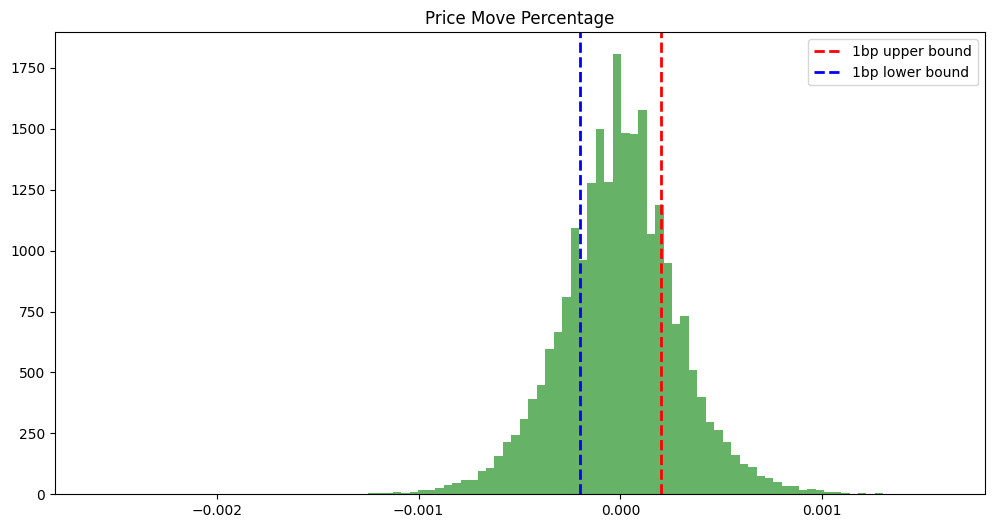

In [13]:
# Calculate percentiles
percentile_50 = np.nanpercentile(df_selected['price_move_pctg'], 50)
p_upper = percentile_50 + 0.0002
p_lower = percentile_50 - 0.0002
print(f"upper bond: {p_upper*100:0.8f}%, lower bond: {p_lower*100:0.8f}%")
plt.figure(figsize=(12, 6))
plt.hist(df_selected['price_move_pctg'], bins=100, density=True, alpha=0.6, color='g')
plt.axvline(x=p_upper, color='r', linestyle='--', linewidth=2, label=f'1bp upper bound')
plt.axvline(x=p_lower, color='b', linestyle='--', linewidth=2, label=f'1bp lower bound')
plt.title('Price Move Percentage')
plt.legend()
plt.show()

In [14]:
def move_label(x, alpha = 0.0002):
    if x > alpha:
        return 1
    elif x < -alpha:
        return -1
    else:
        return 0

In [16]:
alpha = 0.0002
df_selected['price_move_label'] = df_selected['price_move_pctg'].apply(lambda x: move_label(x, alpha))
df_selected['price_move_label'].value_counts(normalize=True)

price_move_label
 0    0.558696
-1    0.227613
 1    0.213692
Name: proportion, dtype: float64

In [17]:
df_selected['price_move_label'].value_counts().values

array([16053,  6540,  6140])

In [11]:
df_selected

,timestamp,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5,price_move,price_move_pctg,price_move_label
0,20260515 09:29:00.113806,8710.5,8710.833333,8710.345455,8707.628571,8710.285714,8708.900000,13.2,0.001515,1
1,20260515 09:30:00.519956,8710.1,8710.175000,8715.400000,8713.666667,8710.333333,8707.440000,13.9,0.001596,1
2,20260515 09:30:01.021552,8713.8,8711.633333,8712.750000,8717.928000,8718.400000,8718.080000,12.8,0.001469,1
3,20260515 09:30:01.519457,8712.4,8712.400000,8714.690323,8714.050000,8714.500000,8715.463158,12.7,0.001458,1
4,20260515 09:30:02.018199,8716.5,8716.500000,8714.977778,8715.266667,8717.720000,8718.355556,10.7,0.001228,1
...,...,...,...,...,...,...,...,...,...,...
28718,20260515 14:59:53.054570,8579.7,8579.945455,8580.627586,8580.300000,8581.100000,8579.150000,2.7,0.000315,1
28719,20260515 14:59:53.555046,8580.9,8581.133333,8581.200000,8581.861538,8583.217391,8581.300000,2.9,0.000338,1
28720,20260515 14:59:54.054941,8582.3,8582.200000,8582.200000,8583.050000,8581.666667,8583.333333,-0.1,-0.000012,0
28721,20260515 14:59:54.555299,8583.3,8583.300000,8583.133333,8583.100000,8583.100000,8583.300000,-1.0,-0.000117,-1


## CNN Structure

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

In [4]:
data = pd.read_csv('Data/Normalized_data/normalized_0515.csv')
data

,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5,price_move_label
0,-0.161597,-0.169145,-0.211277,-0.169990,-0.191387,1
1,-0.171812,-0.090717,-0.117581,-0.169251,-0.214044,1
2,-0.149185,-0.131836,-0.051456,-0.044073,-0.048925,1
3,-0.137290,-0.101729,-0.111633,-0.104593,-0.089535,1
4,-0.073677,-0.097269,-0.092753,-0.054625,-0.044649,1
...,...,...,...,...,...,...
28718,-2.192380,-2.181886,-2.187087,-2.174688,-2.204931,1
28719,-2.173950,-2.173004,-2.162856,-2.141830,-2.171566,1
28720,-2.157400,-2.157488,-2.144414,-2.165894,-2.140012,0
28721,-2.140333,-2.143006,-2.143639,-2.143652,-2.140529,-1


In [5]:
tc_data = torch.tensor(data.values, dtype=torch.float32)
len(tc_data)

28723

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data: torch.Tensor, window_size: int = 200, target_size: int = 1):
        self.data = data
        self.window_size = window_size
        self.target_size = target_size

    def __len__(self):
        return len(self.data) - self.window_size - self.target_size + 1
    
    def __getitem__(self, idx):
        x_start = idx
        x_end = idx + self.window_size
        X = self.data[x_start:x_end, :-1]  # Features

        y_start = x_end
        y_end = x_end + self.target_size
        Y = self.data[y_start:y_end, -1]  # Target label

        return X, Y

### Prepared Dataset

In [42]:
from pathlib import Path 

all_daily_ds = []

csv_files = sorted(Path('Data/Normalized_data').glob('normalized_*.csv'))
csv_files_for_training = csv_files[:8]
print(f'{len(csv_files)}) csv files found.\n{len(csv_files_for_training)} files will be used for training.')

label_counts_overall = np.zeros(3, dtype=int)  # To count occurrences of each label across all files
for file in csv_files_for_training:
    df = pd.read_csv(file)
    df['price_move_label'] = df['price_move_label'] + 1  # Shift labels from [-1, 0, 1] to [0, 1, 2]
    label_counts = df['price_move_label'].iloc[200:].value_counts().sort_index().values
    label_counts_overall += label_counts
    tc_data = torch.tensor(df.values, dtype=torch.float32)

    # Defensively check if length of df is sufficient for creating a dataset
    if len(df) < 200 + 1:  # window_size + target_size
        print(f"Warning: {file} has insufficient data ({len(df)} rows). Skipping this file.")
        continue
    
    ts_dataset = TimeSeriesDataset(tc_data, window_size=200, target_size=1)
    all_daily_ds.append(ts_dataset)

label_names = ['Down', 'Stationary', 'Up']

final_dataset = ConcatDataset(all_daily_ds)

# DataLoader
train_loader = DataLoader(final_dataset, batch_size=32, shuffle=True)

print(f'\nTotal days used for training: {len(all_daily_ds)}')
print(f'Total samples in final dataset: {len(final_dataset)}')

X_sample, Y_sample = final_dataset[0]
print(f'\nSample X shape: {X_sample.shape}, Sample Y shape: {Y_sample.shape}')

print(f'\nBatch Size: {train_loader.batch_size}')
print(f'Total number of batches per epoch: {len(train_loader)}')

for batch_idx, (data, label) in enumerate(train_loader):
    print(f"\nData shape: {data.shape}") 
    print(f"Label shape: {label.shape}")
    break
label_df = pd.DataFrame(label_counts_overall, index=label_names, columns=['Count'])
print("\nLabel distribution across all training files:")
label_df

10) csv files found.
8 files will be used for training.

Total days used for training: 8
Total samples in final dataset: 223702

Sample X shape: torch.Size([200, 5]), Sample Y shape: torch.Size([1])

Batch Size: 32
Total number of batches per epoch: 6991

Data shape: torch.Size([32, 200, 5])
Label shape: torch.Size([32, 1])

Label distribution across all training files:


,Count
Down,52862
Stationary,115181
Up,55659


In [37]:
class DeepLOB(nn.Module):
    def __init__(self, num_features: int, num_classes: int = 3):
        super().__init__()

        # Convolutional layers
        self.causal_pad = nn.ZeroPad2d((0, 0, 3, 0))  # Pad only on the top for time dimension

        self.conv_time1 = nn.Conv2d(1, 16, kernel_size=(4, 1))
        self.conv_time2 = nn.Conv2d(16, 16, kernel_size=(4, 1))
        self.conv_time3 = nn.Conv2d(16, 16, kernel_size=(4, 1))
        self.conv_time4 = nn.Conv2d(16, 16, kernel_size=(4, 1))
        self.conv_feat1 = nn.Conv2d(16, 16, kernel_size=(1, num_features))
        self.conv_time5 = nn.Conv2d(16, 16, kernel_size=(4, 1))
        self.conv_time6 = nn.Conv2d(16, 16, kernel_size=(4, 1))

        # Inception layer would be defined here (not implemented in this simple version)
        self.incp_Path1_1 = nn.Conv2d(16, 32, kernel_size=(1,1))
        self.incp_Path1_pad = nn.ZeroPad2d((0, 0, 2, 0))  # Pad only on the top for time dimension
        self.incp_Path1_2 = nn.Conv2d(32, 32, kernel_size=(3,1))

        self.incp_Path2_1 = nn.Conv2d(16, 32, kernel_size=(1,1))
        self.incp_Path2_pad = nn.ZeroPad2d((0, 0, 4, 0))  # Pad only on the top for time dimension
        self.incp_Path2_2 = nn.Conv2d(32, 32, kernel_size=(5,1))

        self.incp_Path3_pad = nn.ZeroPad2d((0, 0, 2, 0))  # Pad only on the top for time dimension
        self.incp_Path3_1 = nn.MaxPool2d(kernel_size=(3,1), stride=(1,1))
        self.incp_Path3_2 = nn.Conv2d(16, 32, kernel_size=(1,1))

        # LSTM layer with 64 hidden units
        self.lstm = nn.LSTM(input_size=96, hidden_size=64, batch_first=True, bidirectional=False)

        # Fully connected layer for classification
        self.head = nn.Linear(64, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [batch, time_steps, num_features]
        x = x.unsqueeze(1)            # [batch, 1, time_steps, num_features]

        # Convolution Blocks
        # Time Convolutions Block1 (4*1)@16
        x = self.causal_pad(x)  # Apply causal padding before the time convolution
        x = F.leaky_relu(self.conv_time1(x), negative_slope=0.01)
       
        # Time Convolutions Block2 (4*1)@16
        x = self.causal_pad(x)  # Apply causal padding before the time convolution
        x = F.leaky_relu(self.conv_time2(x), negative_slope=0.01)
        
        # Time Convolutions Block3 (4*1)@16
        x = self.causal_pad(x)  # Apply causal padding before the time convolution
        x = F.leaky_relu(self.conv_time3(x), negative_slope=0.01)
        
        # Time Convolutions Block4 (4*1)@16
        x = self.causal_pad(x)  # Apply causal padding before the time convolution
        x = F.leaky_relu(self.conv_time4(x), negative_slope=0.01)
        
        # Feature Convolution (1*10)@16
        x = F.leaky_relu(self.conv_feat1(x), negative_slope=0.01)

        # Time Convolutions Block5 (4*1)@16
        x = self.causal_pad(x)  # Apply causal padding before the time convolution
        x = F.leaky_relu(self.conv_time5(x), negative_slope=0.01)

        # Time Convolutions Block6 (4*1)@16  RF = 1 + 6 * (4-1) = 19
        x = self.causal_pad(x)  # Apply causal padding before the time convolution
        x = F.leaky_relu(self.conv_time6(x), negative_slope=0.01)
        # Output shape after conv_time6: [batch, 16, time_steps:200, features:1] 

        # Inception Block
        # Path 1: (1*1)@32 -> (3*1)@32
        x_path1 = F.leaky_relu(self.incp_Path1_1(x), negative_slope=0.01)
        x_path1 = self.incp_Path1_pad(x_path1)
        x_path1 = F.leaky_relu(self.incp_Path1_2(x_path1), negative_slope=0.01)

        # Path 2: (1*1)@32 -> (5*1)@32
        x_path2 = F.leaky_relu(self.incp_Path2_1(x), negative_slope=0.01)
        x_path2 = self.incp_Path2_pad(x_path2)
        x_path2 = F.leaky_relu(self.incp_Path2_2(x_path2), negative_slope=0.01)

        # Path 3: MaxPool(3*1) -> (1*1)@32
        x_path3 = self.incp_Path3_pad(x)
        x_path3 = self.incp_Path3_1(x_path3)
        x_path3 = F.leaky_relu(self.incp_Path3_2(x_path3), negative_slope=0.01)

        x = torch.cat([x_path1, x_path2, x_path3], dim=1)  # Concatenate along the channel dimension
        # Output shape after concatenation: [batch, 96, time_steps:200, features:1]

        # LSTM Block
        # Reshape from [batch, 96, time_steps, features:1] to [batch, time_steps, features:96]
        x = x.squeeze(3).transpose(1, 2)
        output, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]  # Take the last hidden state from the LSTM and reshape to [batch, hidden_size]
             
        # Dense
        x = self.head(x)        
        
        return x

# Example instantiation
num_features = X_sample.shape[-1]
model = DeepLOB(num_features=num_features, num_classes=3)
print(model)
params_num = sum(p.numel() for p in model.parameters())
print(f'\nTotal number of parameters: {params_num}')

print(f'\nInput sample shape: {X_sample.shape}')
print(f'Example output shape: {model(X_sample.unsqueeze(0)).shape}')

DeepLOB(
  (causal_pad): ZeroPad2d((0, 0, 3, 0))
  (conv_time1): Conv2d(1, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time2): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time3): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time4): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_feat1): Conv2d(16, 16, kernel_size=(1, 5), stride=(1, 1))
  (conv_time5): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time6): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (incp_Path1_1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (incp_Path1_pad): ZeroPad2d((0, 0, 2, 0))
  (incp_Path1_2): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1))
  (incp_Path2_1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (incp_Path2_pad): ZeroPad2d((0, 0, 4, 0))
  (incp_Path2_2): Conv2d(32, 32, kernel_size=(5, 1), stride=(1, 1))
  (incp_Path3_pad): ZeroPad2d((0, 0, 2, 0))
  (incp_Path3_1): MaxPool2d(kernel_size=(3, 1), stride=(1, 1), padding=0, dilation=1, 

In [38]:
def train_model(model, train_loader, optimizer, criterion, device):
    model.train()  # Set model to training mode
    total_loss = 0.0

    pbar = tqdm(train_loader, desc="Training", unit="batch")
        
    for i, (data, label) in enumerate(pbar):
        data, label = data.to(device), label.to(device).long().squeeze()  # Ensure labels are the correct shape and type

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        
        optimizer.step()

        total_loss += loss.item()

        current_avg_loss = total_loss / (i + 1)
        pbar.set_postfix({'loss': f'{current_avg_loss:.4f}'})

    avg_loss = total_loss / len(train_loader)

    return avg_loss
    

In [44]:
num_features = 5

class_weights = label_df['Count'].sum() / (label_df['Count'] * len(label_df))
weights = torch.tensor(class_weights.values, dtype=torch.float32)
print(f"\nClass weights for CrossEntropyLoss:{weights}")

learning_rate = 0.01 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DeepLOB(num_features=num_features, num_classes=3)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

print("Overfitting Batch test...")
x_fixed, y_fixed = next(iter(train_loader))
x_fixed, y_fixed = x_fixed.to(device), y_fixed.to(device).long().squeeze()
x_fixed = torch.clamp(x_fixed, min=-3.0, max=3.0)

final_loss = 0.0
model.train()
for iteration in range(1, 101):
    optimizer.zero_grad()
    output = model(x_fixed)
    loss = criterion(output, y_fixed)
    final_loss = loss.item()
    loss.backward()
    optimizer.step()
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}: Loss = {loss.item():.4f}")
if final_loss < 0.01:
    print("\nOverfitting test passed! The model can fit a small batch of data.")
else:
    print("\nOverfitting test failed. The model did not fit the small batch of data well.")



Class weights for CrossEntropyLoss:tensor([1.4106, 0.6474, 1.3397])
Overfitting Batch test...
Iteration 10: Loss = 1.0678
Iteration 20: Loss = 1.0563
Iteration 30: Loss = 0.9890
Iteration 40: Loss = 0.8729
Iteration 50: Loss = 0.8961
Iteration 60: Loss = 0.8995
Iteration 70: Loss = 0.8186
Iteration 80: Loss = 0.8546
Iteration 90: Loss = 0.8994
Iteration 100: Loss = 0.9601

Overfitting test failed. The model did not fit the small batch of data well.


In [45]:
next(iter(train_loader))[0]

tensor([[[0.8035, 0.7982, 0.7711, 0.7758, 0.8083],
         [0.7980, 0.8018, 0.7711, 0.7758, 0.8083],
         [0.7939, 0.7891, 0.7874, 0.7682, 0.7841],
         ...,
         [0.8453, 0.8536, 0.8365, 0.8381, 0.8509],
         [0.8428, 0.8553, 0.8698, 0.8640, 0.8329],
         [0.8525, 0.8838, 0.8656, 0.8454, 0.8696]],

        [[1.9242, 1.9251, 1.9274, 1.9196, 1.9207],
         [1.9237, 1.9236, 1.9264, 1.9288, 1.9163],
         [1.9213, 1.9229, 1.9190, 1.9229, 1.9244],
         ...,
         [1.9454, 1.9450, 1.9431, 1.9543, 1.9524],
         [1.9412, 1.9470, 1.9466, 1.9443, 1.9362],
         [1.9486, 1.9477, 1.9466, 1.9436, 1.9490]],

        [[1.8092, 1.8057, 1.8085, 1.8034, 1.8038],
         [1.8082, 1.8133, 1.8057, 1.8085, 1.8094],
         [1.8082, 1.8086, 1.8070, 1.8067, 1.8021],
         ...,
         [1.7756, 1.7774, 1.7730, 1.7785, 1.7778],
         [1.7760, 1.7777, 1.7736, 1.7747, 1.7816],
         [1.7752, 1.7777, 1.7736, 1.7747, 1.7816]],

        ...,

        [[1.7844, 1.

In [40]:
num_features = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

weights = weights.to(device)

test_model = DeepLOB(num_features=num_features, num_classes=3, weights=weights, learning_rate=0.01)
test_overfit_small_batch(test_model, train_loader, device)

TypeError: DeepLOB.__init__() got an unexpected keyword argument 'weights'

In [ ]:
num_features = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

weights = weights.to(device)

test_model = DeepLOB(num_features=num_features, num_classes=3, weights=weights, learning_rate=0.01)

loss_history = []
num_epochs = 10

print('Start training...')

for epoch in range(num_epochs):
    test_model.train()
    avg_loss = test_model.train_model(train_loader, device=device)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    test_model.eval()

Start training...


Training:   0%|          | 34/6991 [00:11<38:46,  2.99batch/s, loss=1.0979]


KeyboardInterrupt: 